# BTC/ETH Rolling Stat-Arb (multi-day)

Continuous, stitched out-of-sample evaluation of a daily BTC/ETH spread strategy.

**Methodology**
- Single pair: BTCUSDT / ETHUSDT, daily bars.
- Fixed a priori z-thresholds (`entry_z=2.0`, `exit_z_tp=0.5`, `exit_z_sl=3.0`); no validation, no param tuning.
- Each refit recalibrates ONLY the hedge ratio (beta) and spread mean/std on the trailing window. Beta is frozen while a position is open.
- The entire post-warmup NAV is out-of-sample by construction and treated as one stitched OOS equity curve. Per-month numbers are diagnostics only — with few multi-day trades they are noisy, so the verdict is the return **t-stat** and the shape of the full curve.

Note: BTC/ETH daily windows rarely pass a formal per-window cointegration test, so `require_cointegration` is left off here (the pair is chosen a priori on economic grounds).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make the repo root importable regardless of where the kernel started.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.run_stat_arb import load_close
from src.strategy.stat_arb.evaluation import evaluate_rolling_oos, rolling_oos_to_dataframe
from src.trading.costs import DEFAULT_COSTS, STRESS_COSTS

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
PAIR = ("BTCUSDT", "ETHUSDT")
INTERVAL = "1d"
START, END = "2024-01-01", "2026-04-30"
WINDOW_BARS = 60    # ~2 months trailing estimation window (diagnostics: 365d too slow)
REFIT_BARS = 7      # recalibrate beta + spread stats weekly

y = load_close(PAIR[0], INTERVAL, START, END)
x = load_close(PAIR[1], INTERVAL, START, END)
print(f"{PAIR[0]}: {len(y)} bars  |  {PAIR[1]}: {len(x)} bars  |  {y.index.min().date()} -> {y.index.max().date()}")

BTCUSDT: 851 bars  |  ETHUSDT: 851 bars  |  2024-01-01 -> 2026-04-30


In [3]:
result = evaluate_rolling_oos(
    y, x,
    pair=PAIR,
    interval=INTERVAL,
    window_bars=WINDOW_BARS,
    refit_bars=REFIT_BARS,
    entry_z=2.0,
    exit_z_tp=0.5,
    exit_z_sl=3.0,
    cooldown_bars=5,
    require_cointegration=False,
    costs=DEFAULT_COSTS,
)

summary = rolling_oos_to_dataframe(result)
print("Return t-stat:", round(result.return_tstat, 2))
print("Profitable months:", f"{result.pct_profitable_months:.0%}")
print("Worst losing streak (months):", result.worst_losing_streak_months)
print("Total fees:", round(result.total_fees, 2), "| Total funding:", round(result.total_funding, 2))
summary.T

Return t-stat: 0.51
Profitable months: 35%
Worst losing streak (months): 6
Total fees: 39.42 | Total funding: 1.5


,0
pair,BTCUSDT/ETHUSDT
interval,1d
params,"{'entry_z': 2.0, 'exit_z_tp': 0.5, 'exit_z_sl'..."
oos_sharpe,0.3476
oos_return,0.0797
oos_max_dd,-0.1656
return_tstat,0.5118
n_trades,55
win_rate,0.1455
gross_pnl,79.6726


## Stitched OOS equity curve and drawdown

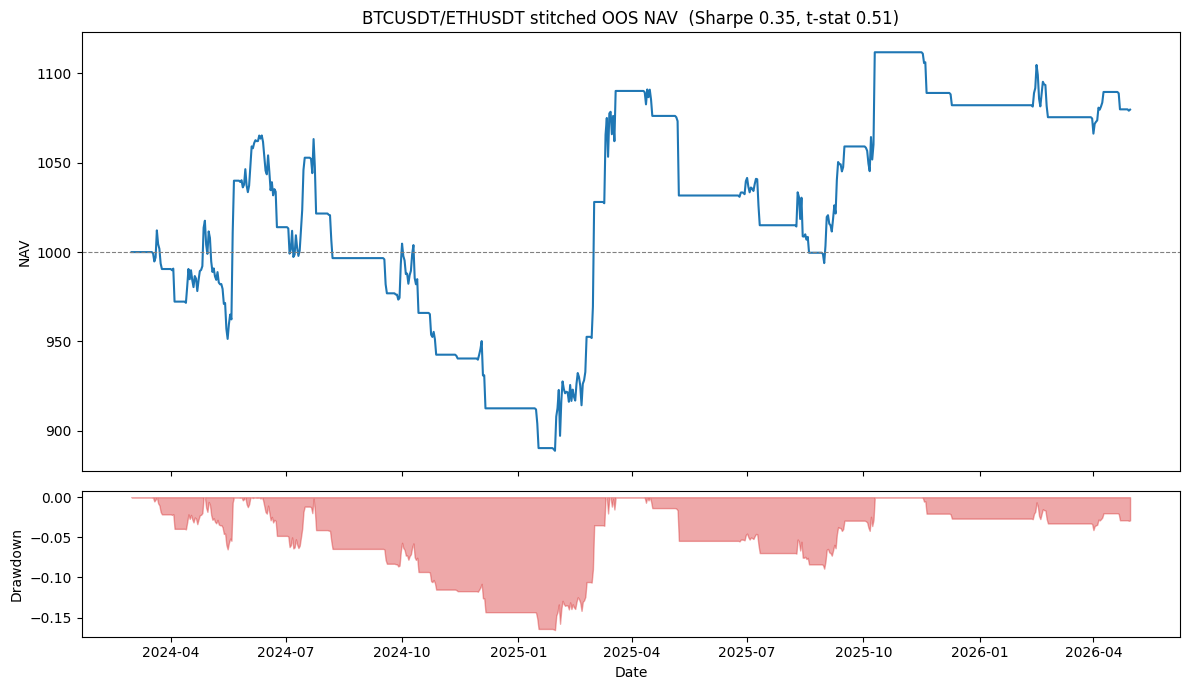

In [4]:
bt = result.bt
nav = bt["nav"]
drawdown = nav / nav.cummax() - 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(nav.index, nav.values, color="tab:blue")
axes[0].axhline(nav.iloc[0], color="grey", ls="--", lw=0.8)
axes[0].set_ylabel("NAV")
axes[0].set_title(f"{PAIR[0]}/{PAIR[1]} stitched OOS NAV  (Sharpe {result.metrics.sharpe:.2f}, t-stat {result.return_tstat:.2f})")

axes[1].fill_between(drawdown.index, drawdown.values, 0, color="tab:red", alpha=0.4)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Hedge ratio (beta) and spread with positions

Beta is recalibrated on the trailing window each refit and frozen while a position is open. Shaded regions mark when the strategy holds a long (green) or short (red) spread position.

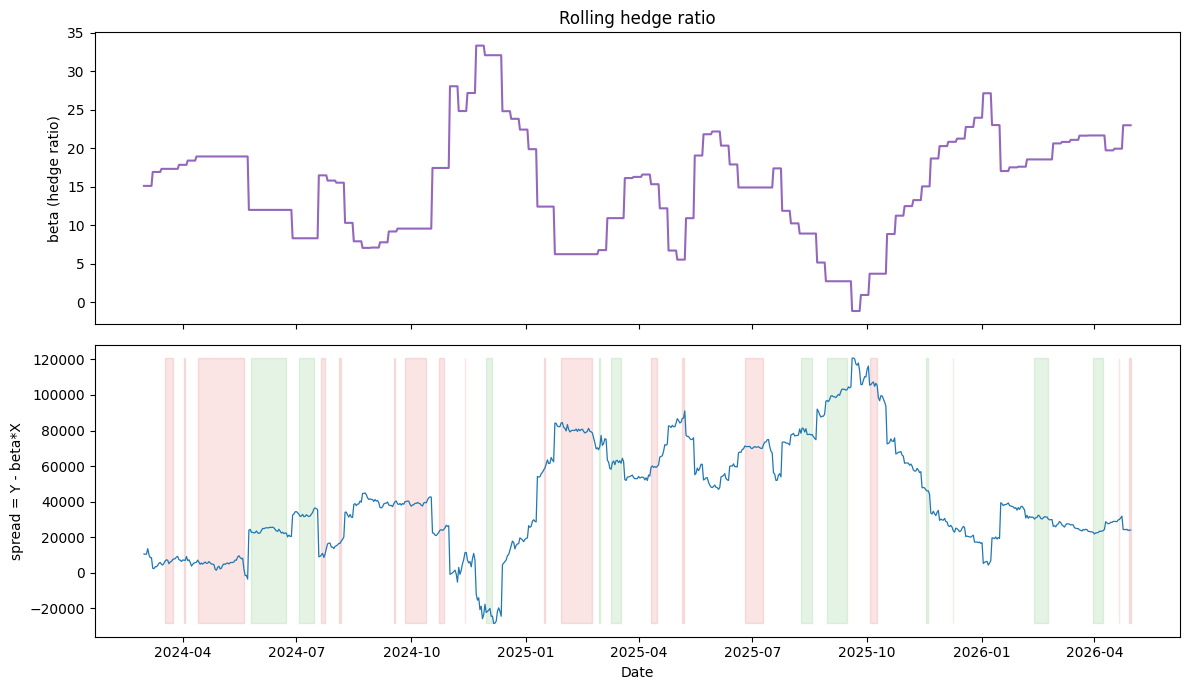

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(bt.index, bt["beta"], color="tab:purple")
axes[0].set_ylabel("beta (hedge ratio)")
axes[0].set_title("Rolling hedge ratio")

axes[1].plot(bt.index, bt["spread"], color="tab:blue", lw=0.9)
axes[1].set_ylabel("spread = Y - beta*X")
axes[1].set_xlabel("Date")

state = bt["position_state"]
for value, color in [(1, "tab:green"), (-1, "tab:red")]:
    axes[1].fill_between(bt.index, bt["spread"].min(), bt["spread"].max(),
                         where=(state == value), color=color, alpha=0.12, step="mid")
plt.tight_layout()
plt.show()

## Per-month diagnostics

Noisy by design (few multi-day trades per month). Use for shape/consistency, not as a gate.

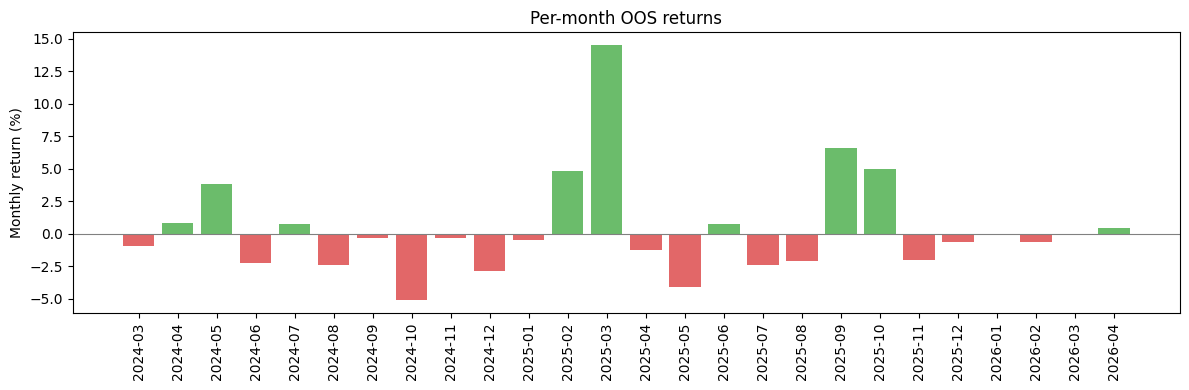

,month,return,sharpe,n_trades,fee,funding
0,2024-03,-0.0095,-1.5831,2,1.4188,-0.1571
1,2024-04,0.0086,0.8245,3,2.0889,0.1079
2,2024-05,0.0384,2.0290,2,1.5275,0.6309
3,2024-06,-0.0226,-2.2851,1,0.6392,1.2884
4,2024-07,0.0075,0.5744,4,2.8938,1.0488
5,2024-08,-0.0244,-5.0910,2,1.3699,-0.2920
6,2024-09,-0.0034,-0.4395,3,2.1114,-0.3118
7,2024-10,-0.0509,-4.7916,3,2.0677,-0.7278
8,2024-11,-0.0030,-5.7477,3,1.9539,0.0265
9,2024-12,-0.0290,-3.4091,1,0.6975,-0.4325


In [6]:
monthly = result.monthly.copy()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["tab:green" if r > 0 else "tab:red" for r in monthly["return"]]
ax.bar(monthly["month"], monthly["return"] * 100, color=colors, alpha=0.7)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Monthly return (%)")
ax.set_title("Per-month OOS returns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly

# Spread diagnostics: is daily BTC/ETH actually mean-reverting?

The baseline above showed no edge. Before tuning thresholds, this section tests the *premise* the whole strategy rests on: does the BTC/ETH spread mean-revert on a daily horizon, and is that property stable through time?

- **Stationarity / cointegration:** Engle-Granger cointegration p-value and an ADF test on the spread (both want p < 0.05).
- **Speed:** half-life of mean reversion (must be short relative to the sample to be tradeable) and the Hurst exponent (< 0.5 = mean-reverting, ~0.5 = random walk).
- **Stability:** rolling beta, cointegration and ADF p-values over time.
- **Conditional reversion:** when |z| >= 2, does the spread actually come back?

In [7]:
from src.strategy.stat_arb.diagnostics import (
    spread_diagnostics,
    reversion_profile,
    rolling_diagnostics,
)

diag = spread_diagnostics(y, x)
print("VERDICT:", diag.verdict())
print()
diag_table = pd.Series({
    "n_obs": diag.n_obs,
    "beta (full sample)": round(diag.beta, 2),
    "cointegration p-value": round(diag.coint_pvalue, 3),
    "ADF p-value (spread)": round(diag.adf_pvalue, 3),
    "half-life (bars)": round(diag.half_life, 1) if diag.half_life else None,
    "Hurst exponent": round(diag.hurst, 3) if diag.hurst else None,
    "% of bars beyond 2 sigma": f"{diag.pct_beyond_2z:.1%}",
})
diag_table.to_frame("value")

VERDICT: NOT reliably mean-reverting: ADF p=0.47 (>=0.05, cannot reject unit root)



,value
n_obs,851
beta (full sample),12.9400
cointegration p-value,0.7060
ADF p-value (spread),0.4650
half-life (bars),191.4000
Hurst exponent,0.4830
% of bars beyond 2 sigma,0.0%


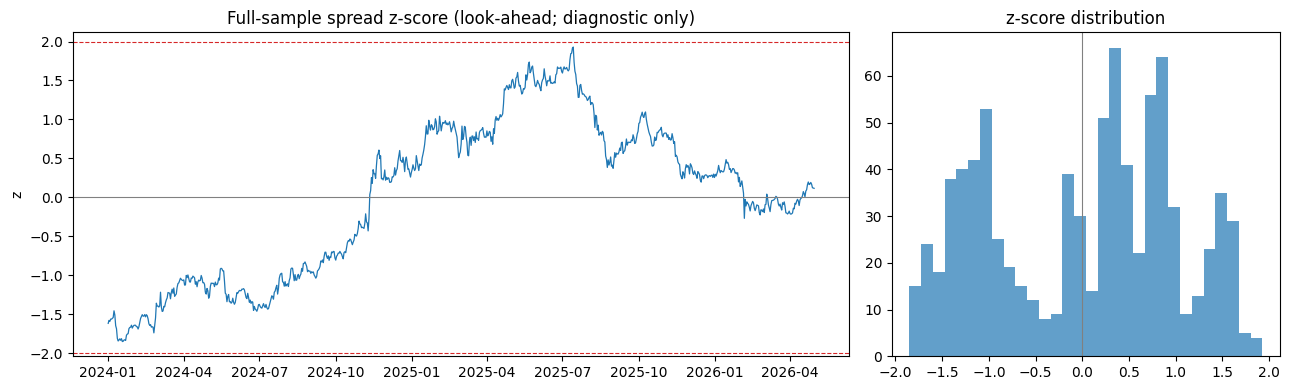

In [8]:
from src.strategy.stat_arb.engine import compute_beta_spread

_, spread_full = compute_beta_spread(y, x)
spread_full = spread_full.dropna()
z_full = (spread_full - spread_full.mean()) / spread_full.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(spread_full.index, z_full.values, color="tab:blue", lw=0.9)
for k in (2, -2):
    axes[0].axhline(k, color="tab:red", ls="--", lw=0.8)
axes[0].axhline(0, color="grey", lw=0.8)
axes[0].set_title("Full-sample spread z-score (look-ahead; diagnostic only)")
axes[0].set_ylabel("z")

axes[1].hist(z_full.values, bins=30, color="tab:blue", alpha=0.7)
axes[1].axvline(0, color="grey", lw=0.8)
axes[1].set_title("z-score distribution")
plt.tight_layout()
plt.show()

### Stability through time (rolling 365-day windows)

Windows cointegrated (p<0.05): 1%   |   spread stationary (ADF p<0.05): 4%
Beta range: 1.49 -> 18.57
Median rolling half-life: 119 bars


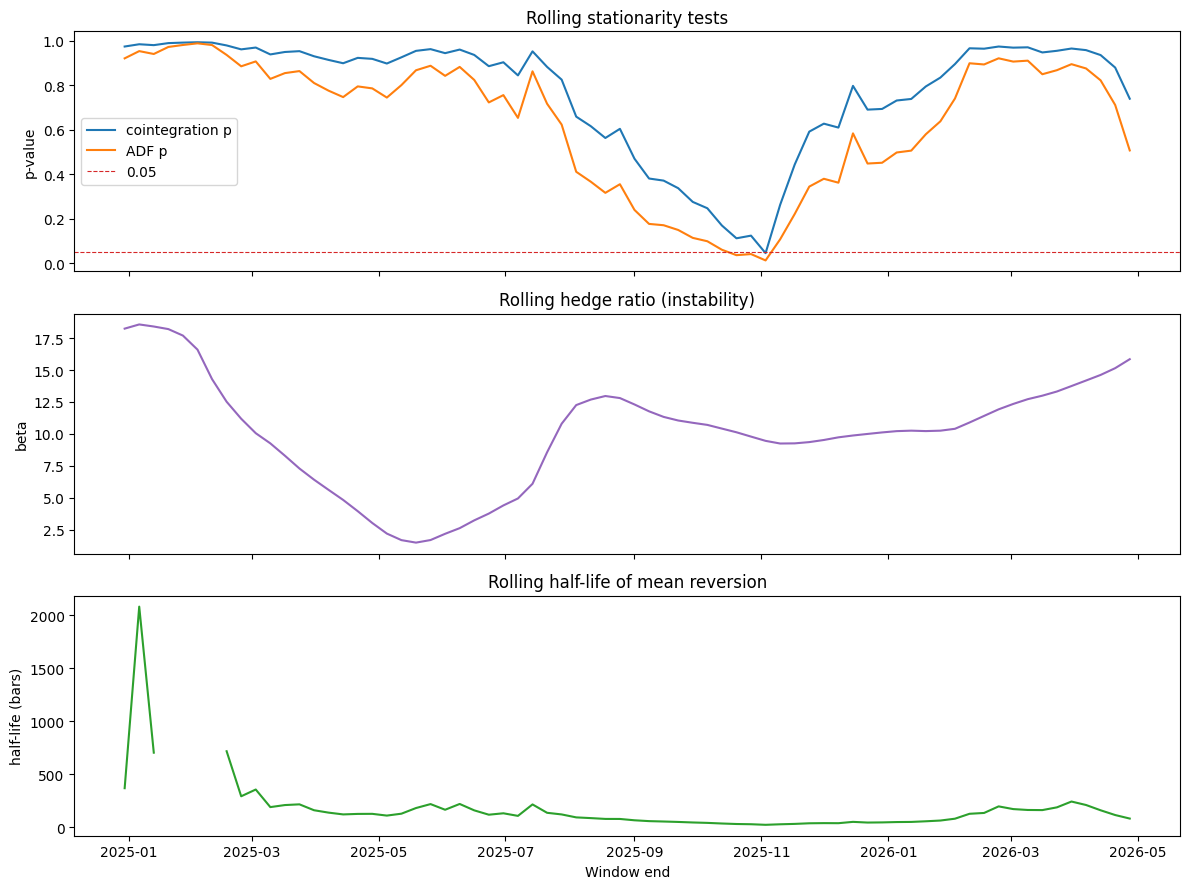

In [9]:
roll = rolling_diagnostics(y, x, window_bars=365, step_bars=7)

frac_coint = (roll["coint_pvalue"] < 0.05).mean()
frac_adf = (roll["adf_pvalue"] < 0.05).mean()
print(f"Windows cointegrated (p<0.05): {frac_coint:.0%}   |   spread stationary (ADF p<0.05): {frac_adf:.0%}")
print(f"Beta range: {roll['beta'].min():.2f} -> {roll['beta'].max():.2f}")
print(f"Median rolling half-life: {roll['half_life'].dropna().median():.0f} bars")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(roll.index, roll["coint_pvalue"], label="cointegration p")
axes[0].plot(roll.index, roll["adf_pvalue"], label="ADF p", color="tab:orange")
axes[0].axhline(0.05, color="tab:red", ls="--", lw=0.8, label="0.05")
axes[0].set_ylabel("p-value"); axes[0].legend(); axes[0].set_title("Rolling stationarity tests")

axes[1].plot(roll.index, roll["beta"], color="tab:purple")
axes[1].set_ylabel("beta"); axes[1].set_title("Rolling hedge ratio (instability)")

axes[2].plot(roll.index, roll["half_life"], color="tab:green")
axes[2].set_ylabel("half-life (bars)"); axes[2].set_title("Rolling half-life of mean reversion")
axes[2].set_xlabel("Window end")
plt.tight_layout()
plt.show()

### Conditional reversion: when |z| >= 2, does the spread come back?

Normalised on a trailing rolling window (what the live strategy actually sees), not full-sample. `mean_reversion` > 0 and `pct_reverted` > 0.5 mean the spread tends to revert after an extreme. Compare a short (90-bar) window against the 365-bar window the backtest used.

window=90 bars:
 horizon_bars  n_signals  mean_reversion  pct_reverted
            1        114          0.0684        0.6140
            3        114          0.2920        0.7632
            5        114          0.3756        0.8070
           10        114          0.5940        0.8421
           20        114          0.9497        0.9035

window=365 bars (as used by the backtest):
 horizon_bars  n_signals  mean_reversion  pct_reverted
            1         58          0.0231        0.5345
            3         58          0.0473        0.7069
            5         58          0.0619        0.7069
           10         58          0.1241        0.7414
           20         58          0.2641        0.7759


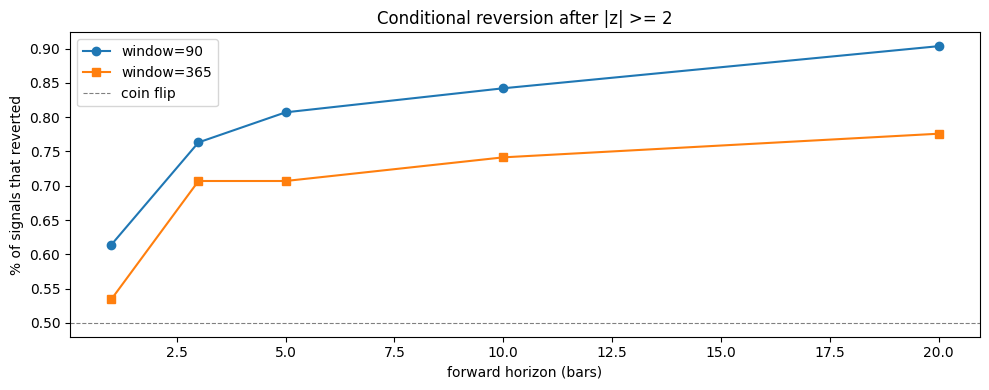

In [10]:
rev_90 = reversion_profile(y, x, z_entry=2.0, window=90)
rev_365 = reversion_profile(y, x, z_entry=2.0, window=365)

print("window=90 bars:")
print(rev_90.to_string(index=False))
print("\nwindow=365 bars (as used by the backtest):")
print(rev_365.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rev_90["horizon_bars"], rev_90["pct_reverted"], "o-", label="window=90")
ax.plot(rev_365["horizon_bars"], rev_365["pct_reverted"], "s-", label="window=365")
ax.axhline(0.5, color="grey", ls="--", lw=0.8, label="coin flip")
ax.set_xlabel("forward horizon (bars)"); ax.set_ylabel("% of signals that reverted")
ax.set_title("Conditional reversion after |z| >= 2"); ax.legend()
plt.tight_layout()
plt.show()

### Verdict

- **Formal stationarity fails.** On the full sample BTC/ETH is not cointegrated (coint p ~ 0.71), the spread is not stationary (ADF p ~ 0.47), Hurst ~ 0.5 (random walk), and half-life is ~100+ days. Across rolling 365-day windows only a tiny fraction are cointegrated/stationary and the hedge ratio (beta) swings wildly (~1.5 to ~18). Daily BTC/ETH is **not a classic cointegrated pair**.
- **But short-window z-extremes do revert** (~84% within 10 days at a 90-bar window), much more than the 365-bar window the backtest used (~74%, weaker magnitude). Caveat: a large part of this is the rolling band adapting to price rather than economic mean reversion, so treat it as a soft signal, not proof of stationarity.
- **Implication:** the original 365-day estimation window is too slow for whatever short-lived reversion exists; the unstable beta is the deeper problem. The most promising next lever is a **shorter estimation/refit window** (and possibly a shorter bar horizon), not the entry/exit thresholds. Genuine stationary cointegration on daily BTC/ETH is not supported by the data.

## Window comparison: 365d vs 60d estimation

Diagnostics showed the 365-day window dilutes short-lived reversion. Below we compare the original baseline against the shorter 60d/7d setup (best Sharpe in a small grid sweep). Caveat: we tested several windows on the same sample, so treat improved metrics as exploratory, not proof.

In [11]:
configs = [
    ("365d / 21d refit (baseline)", 365, 21),
    ("60d / 7d refit", 60, 7),
    ("90d / 7d refit", 90, 7),
    ("120d / 7d refit", 120, 7),
]

cmp_rows = []
cmp_results = {}
for name, w, r in configs:
    res = evaluate_rolling_oos(
        y, x, pair=PAIR, interval=INTERVAL,
        window_bars=w, refit_bars=r,
        entry_z=2.0, exit_z_tp=0.5, exit_z_sl=3.0, cooldown_bars=5,
        require_cointegration=False, costs=DEFAULT_COSTS,
    )
    cmp_results[name] = res
    m = res.metrics
    cmp_rows.append({
        "config": name,
        "window": w,
        "refit": r,
        "sharpe": m.sharpe,
        "return": m.total_return,
        "max_dd": m.max_drawdown,
        "t_stat": res.return_tstat,
        "trades": m.n_trades,
        "fees": res.total_fees,
        "funding": res.total_funding,
    })

cmp = pd.DataFrame(cmp_rows).sort_values("sharpe", ascending=False)
cmp

,config,window,refit,sharpe,return,max_dd,t_stat,trades,fees,funding
1,60d / 7d refit,60,7,0.3476,0.0797,-0.1656,0.5118,55,39.4179,1.5048
0,365d / 21d refit (baseline),365,21,0.1708,0.0179,-0.2074,0.1971,11,7.0835,-27.0026
2,90d / 7d refit,90,7,-0.1343,-0.0553,-0.2682,-0.1939,45,29.2557,-0.1661
3,120d / 7d refit,120,7,-0.5894,-0.1475,-0.3166,-0.8340,40,26.6908,-1.3401


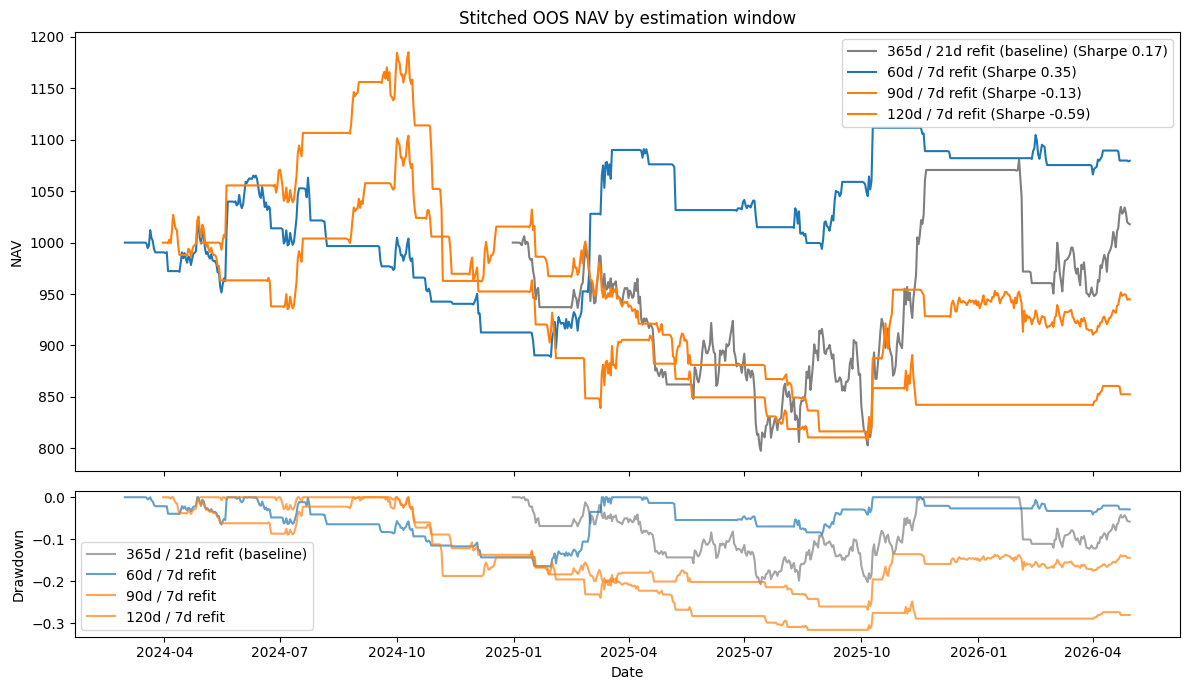

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
colors = {"365d / 21d refit (baseline)": "tab:grey", "60d / 7d refit": "tab:blue"}

for name, res in cmp_results.items():
    nav = res.bt["nav"]
    dd = nav / nav.cummax() - 1
    c = colors.get(name, "tab:orange")
    axes[0].plot(nav.index, nav.values, label=f"{name} (Sharpe {res.metrics.sharpe:.2f})", color=c)
    axes[1].plot(dd.index, dd.values, label=name, color=c, alpha=0.7)

axes[0].set_ylabel("NAV"); axes[0].legend(); axes[0].set_title("Stitched OOS NAV by estimation window")
axes[1].set_ylabel("Drawdown"); axes[1].set_xlabel("Date"); axes[1].legend()
plt.tight_layout()
plt.show()

## 4h bars (multi-day horizon, finer resolution)

The best **1d** config was `60/7` (60 **daily** bars ≈ 2 months, refit every 7 days). On **4h**, the same calendar span is `360/42` bars (6 four-hour bars per day). We also tried shorter/longer 4h windows. **Result: 1d still beats every 4h config on this sample** — higher turnover and fees on 4h dominate. Least-bad 4h: `540/42` (~90d window), Sharpe ~0.31 vs 1d ~0.35.

In [ ]:
y4 = load_close(PAIR[0], "4h", START, END)
x4 = load_close(PAIR[1], "4h", START, END)
print(f"4h bars: {len(y4)} ({y4.index.min().date()} -> {y4.index.max().date()})")

configs_4h = [
    ("1d 60/7 (best daily)", "1d", y, x, 60, 7, 5),
    ("4h 360/42 (~60d/7d)", "4h", y4, x4, 360, 42, 30),
    ("4h 540/42 (~90d/7d)", "4h", y4, x4, 540, 42, 30),
    ("4h 180/42 (~30d/7d)", "4h", y4, x4, 180, 42, 30),
]

rows_4h = []
for name, interval, yy, xx, w, r, cd in configs_4h:
    res = evaluate_rolling_oos(
        yy, xx, pair=PAIR, interval=interval,
        window_bars=w, refit_bars=r, cooldown_bars=cd,
        entry_z=2.0, exit_z_tp=0.5, exit_z_sl=3.0,
        require_cointegration=False, costs=DEFAULT_COSTS,
    )
    m = res.metrics
    rows_4h.append({
        "config": name, "sharpe": m.sharpe, "return": m.total_return,
        "max_dd": m.max_drawdown, "t_stat": res.return_tstat,
        "trades": m.n_trades, "fees": res.total_fees,
    })
pd.DataFrame(rows_4h).sort_values("sharpe", ascending=False)

## Pair comparison (BTC/ETH vs alts)

Perp data extended to BNB and SOL. Same rolling setup (`1d 60/7`, fixed z-thresholds). **BNB/SOL** beats BTC/ETH on 1d; **BTC/SOL @ 4h 360/42** is the strongest config in the scan (Sharpe ~0.78, t-stat ~1.14 — still below 2.0).

In [ ]:
from itertools import combinations

ALT_SYMBOLS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT"]
alt_prices = {s: load_close(s, "1d", START, END) for s in ALT_SYMBOLS}

pair_rows = []
for y_sym, x_sym in combinations(ALT_SYMBOLS, 2):
    res = evaluate_rolling_oos(
        alt_prices[y_sym], alt_prices[x_sym],
        pair=(y_sym, x_sym), interval="1d",
        window_bars=60, refit_bars=7, cooldown_bars=5,
        require_cointegration=False, costs=DEFAULT_COSTS,
    )
    m = res.metrics
    pair_rows.append({
        "pair": f"{y_sym}/{x_sym}",
        "sharpe": m.sharpe,
        "return": m.total_return,
        "max_dd": m.max_drawdown,
        "t_stat": res.return_tstat,
        "trades": m.n_trades,
    })
pd.DataFrame(pair_rows).sort_values("sharpe", ascending=False)

In [ ]:
# Best 4h pair from scan: BTC/SOL
y_btc = load_close("BTCUSDT", "4h", START, END)
y_sol = load_close("SOLUSDT", "4h", START, END)
btc_sol_4h = evaluate_rolling_oos(
    y_btc, y_sol, pair=("BTCUSDT", "SOLUSDT"), interval="4h",
    window_bars=360, refit_bars=42, cooldown_bars=30,
    require_cointegration=False, costs=DEFAULT_COSTS,
)
m = btc_sol_4h.metrics
print(f"BTC/SOL 4h 360/42: Sharpe {m.sharpe:.2f}, return {m.total_return:.2%}, t-stat {btc_sol_4h.return_tstat:.2f}, trades {m.n_trades}")
rolling_oos_to_dataframe(btc_sol_4h).T

## Stability check: SOL/ADA, XRP/ADA vs BNB/SOL

Does the edge survive 2025, or is it front-loaded like BNB/SOL? Compare opens, PnL by year, and beta stability. Plots saved to `results/*_spread_beta.png`.

In [ ]:
stability_cases = [
    ("SOL/ADA 1d", "SOLUSDT", "ADAUSDT", "1d", 60, 7, 5),
    ("XRP/ADA 4h", "XRPUSDT", "ADAUSDT", "4h", 360, 42, 30),
    ("BNB/SOL 1d", "BNBUSDT", "SOLUSDT", "1d", 60, 7, 5),
]

stab_rows = []
for label, ys, xs, iv, w, r, cd in stability_cases:
    res = evaluate_rolling_oos(
        load_close(ys, iv, START, END), load_close(xs, iv, START, END),
        pair=(ys, xs), interval=iv, window_bars=w, refit_bars=r, cooldown_bars=cd,
        require_cointegration=False, costs=DEFAULT_COSTS,
    )
    monthly = res.monthly.copy()
    monthly["year"] = monthly["month"].str[:4]
    for yr, grp in monthly.groupby("year"):
        stab_rows.append({
            "pair": label,
            "year": yr,
            "return": grp["return"].sum(),
            "n_trades": grp["n_trades"].sum(),
            "sharpe_full": res.metrics.sharpe,
            "t_stat_full": res.return_tstat,
        })
pd.DataFrame(stab_rows).pivot_table(index="pair", columns="year", values="return", aggfunc="sum")

## Train 2024 / test 2025+ — XRP/ADA @ 4h

Fixed params (`360/42`, z=2/0.5/3). Train metrics are on 2024 only; test is never used for tuning.

In [ ]:
from src.strategy.stat_arb.evaluation import evaluate_rolling_oos_train_test, train_test_to_dataframe

xrp_ada_split = evaluate_rolling_oos_train_test(
    load_close("XRPUSDT", "4h", START, END),
    load_close("ADAUSDT", "4h", START, END),
    pair=("XRPUSDT", "ADAUSDT"),
    interval="4h",
    window_bars=360,
    refit_bars=42,
    cooldown_bars=30,
    train_start="2024-01-01",
    train_end="2024-12-31",
    test_start="2025-01-01",
    test_end=END,
    require_cointegration=False,
    costs=DEFAULT_COSTS,
)
train_test_to_dataframe(xrp_ada_split).T

## Paper trading (Binance futures testnet)

Two stat-arb strategies run on **4h** bars with fixed research params:

| Strategy | Pair | Window / refit |
|---|---|---|
| `btc_sol_4h` | BTCUSDT / SOLUSDT | 360 / 42 |
| `xrp_ada_4h` | XRPUSDT / ADAUSDT | 360 / 42 |

### API keys — where to save them

1. Copy the template: `cp .env.example .env` (in the repo root)
2. Edit `.env` and paste your **testnet** keys (file is gitignored — never commit it)
3. Get keys from [Binance futures testnet](https://testnet.binancefuture.com/)

```bash
# .env (repo root — NOT committed)
BINANCE_TESTNET_API_KEY=...
BINANCE_TESTNET_API_SECRET=...
```

Alternatively export in your shell or `~/.zshrc`, but `.env` is simplest for this project.

### Commands

```bash
# 1) Dry-run (signals only, no orders)
.venv/bin/python scripts/run_stat_arb_paper_trading.py --dry-run

# 2) Live testnet orders (both strategies)
.venv/bin/python scripts/run_stat_arb_paper_trading.py

# 3) One strategy, custom NAV per strategy
.venv/bin/python scripts/run_stat_arb_paper_trading.py --strategy btc_sol_4h --init-nav 5000
```

Schedule every **4 hours** after the bar closes (cron: `5 */4 * * *`).

Logs: `results/stat_arb_paper_trading_log.csv` · State: `results/paper_stat_arb/*_state.json`

In [ ]:
# Dry-run: verify both strategies load data and produce signals (no API keys needed)
import subprocess, sys, json

proc = subprocess.run(
    [sys.executable, "scripts/run_stat_arb_paper_trading.py", "--dry-run"],
    cwd=str(ROOT),
    capture_output=True,
    text=True,
)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
else:
    print("OK — check results/stat_arb_paper_trading_log.csv for the latest row")

In [ ]:
# Live testnet run (requires .env with BINANCE_TESTNET_API_KEY / SECRET)
import os
from pathlib import Path

env_path = ROOT / ".env"
has_key = bool(os.environ.get("BINANCE_TESTNET_API_KEY")) or env_path.exists()
if not has_key:
    print("No API keys found. Create .env from .env.example first.")
else:
    proc = subprocess.run(
        [sys.executable, "scripts/run_stat_arb_paper_trading.py"],
        cwd=str(ROOT),
        capture_output=True,
        text=True,
    )
    print(proc.stdout)
    if proc.stderr:
        print(proc.stderr)
    print(f"exit code: {proc.returncode}")